# Section 5: paper-aligned conditional random-effects experiments\n

## How to use this notebook

This notebook **reads results and plots**.  It runs no experiment and touches no
raw data, so it executes in seconds.

The experiments live in `experiments/simulation/` and are run separately:

```
python -m experiments.simulation.run            # full
python -m experiments.simulation.run --smoke    # reduced, to check the pipeline
```

That writes `results/simulation/`, which is what the cells below read.  The
estimator, the risk formulas and the shared visual style come from the `rcb`
package.


## 0. Configuration and shared visual style

In [1]:

%matplotlib inline
import sys
from pathlib import Path

CODE = Path.cwd()
if str(CODE) not in sys.path:
    sys.path.insert(0, str(CODE))

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from rcb import paths
from rcb.style import (
    COLORS, COMPONENT_COLORS, COMPONENT_DISPLAY_LABELS, configure_style,
)
from experiments.simulation.dgp import DEFAULT_CONFIG, SCENARIOS

configure_style()
CFG = DEFAULT_CONFIG
STUDY = "simulation"
RESULTS = paths.results(STUDY, create=False)
FIGURES = paths.figures(STUDY)
ARTIFACT_DIR = RESULTS          # the plotting code below reads through these
FIGURE_DIR = FIGURES

COMPONENTS = ("Signal", "Residual noise", "Total")
COMPONENT_COLUMNS = {
    "Signal": ("exact_signal", "estimate_signal", "theoretical_signal"),
    "Residual noise": ("exact_residual", "estimate_residual", "theoretical_residual"),
    "Total": ("exact_total", "estimate_total", "theoretical_total"),
}


def _save(fig, stem):
    """Write the figure as PDF, then show it.

    Manuscript filenames are handled by sync_manuscript_figures.py, so there is
    no second copy under an alias here.
    """
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", dpi=300, bbox_inches="tight",
                pad_inches=0.22, facecolor="white")
    plt.show()


print(pd.read_csv(RESULTS / "configuration.csv").T.to_string())
print("All figures use DejaVu Sans, 12-point ticks, 14-point labels, "
      "compact legends, and no overall title.")


                                     0
seed                          20260802
r2                                 1.0
sigma2                             0.5
etas                           0;0.5;1
calibration_etas          0;0.5;0.75;1
lambda_min                        0.02
lambda_max                        30.0
lambda_count                        25
phi0                              0.75
phi1                              0.75
dimensions              80;160;320;640
deterministic_designs               24
aspect_dimension                  1280
aspect_designs                      24
rho_ar                             0.5
inference_designs                   36
outcomes_per_design                100
base_ridge_penalty                 1.0
nuisance_designs                    24
nuisance_outcomes                   50
split_designs                       18
split_outcomes                      40
calibration_shift_rho2             0.5
sparse_shift_fraction              0.1
pilot_fraction           

## 1. Experiment I: AR(1) risk paths (Figure 1)

Source and target share the AR(1) covariance `Sigma0 = Sigma1`,
`(Sigma0)_{jk} = rho_AR**|j-k|` with `rho_AR = 0.5`.  The shift direction is
fixed to the high-spectrum eigenvector of `Sigma0` (`G_{delta,p} =
delta_{s_p}`) throughout, and columns vary `(rho_eta^2, varrho_eta^2)` over
`(1,0)`, `(0,1)`, `(1,1)` -- the same scenario grid as the isotropic control
in Appendix E, so the two are directly comparable column by column.
*Deterministic equivalent* is the finite-dimensional theory, *exact
conditional risk* the exact risk for the fixed design, and *feasible risk
estimate* the feasible plug-in risk under repeated outcomes.  The star marks
the grid point nearest the median of the 200 selected penalties.


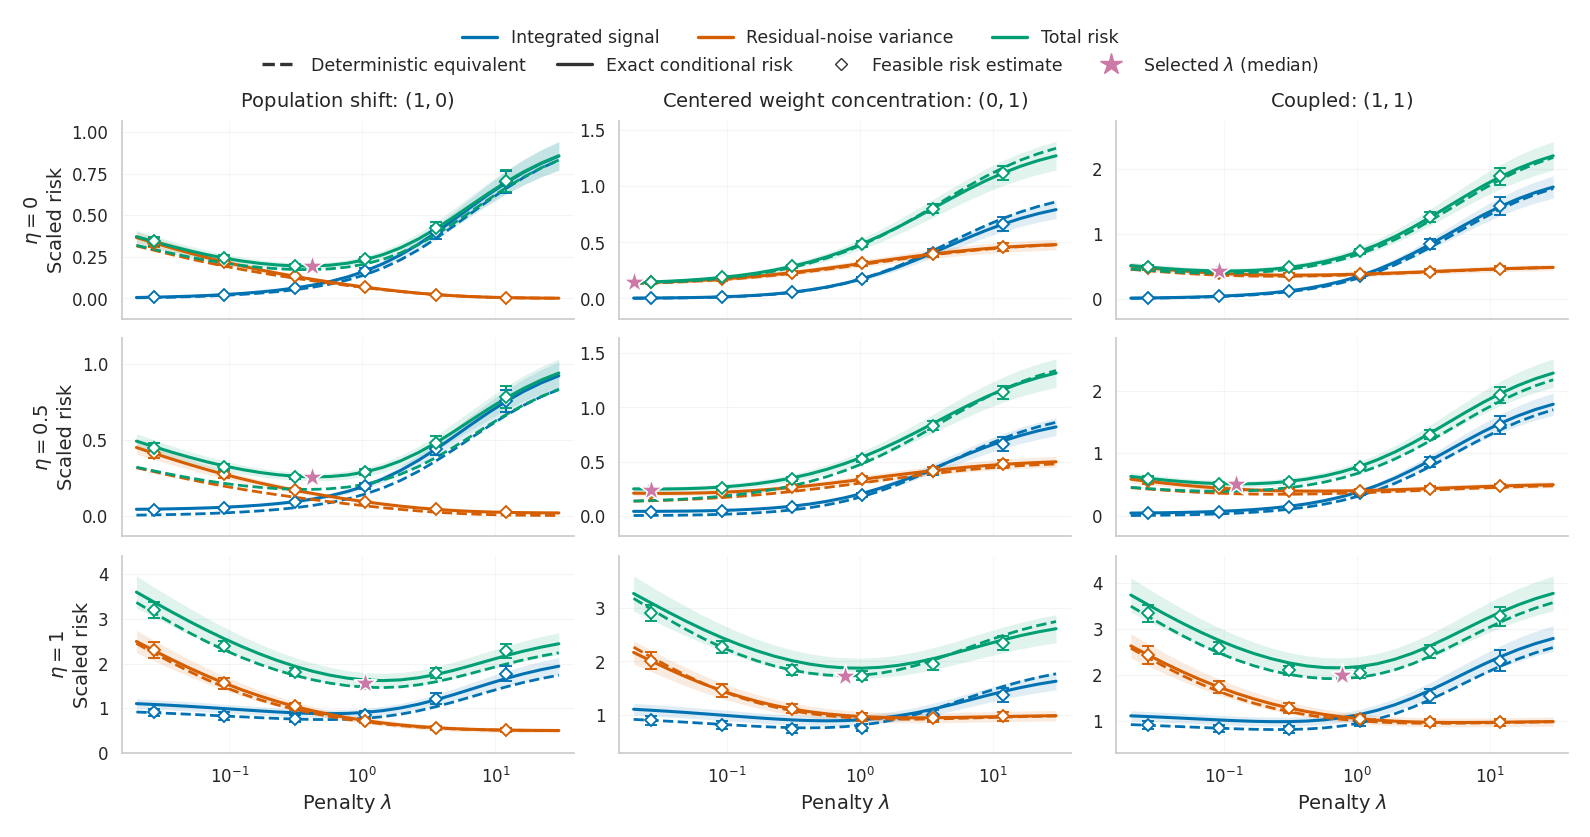

In [2]:
s = pd.read_csv(RESULTS / "ar1_main_risk_summary.csv")
tune = pd.read_csv(RESULTS / "ar1_main_selected_lambda.csv")

SCENARIO_TITLES = {
    "Population shift only": r"Population shift: $(1,0)$",
    "Weight concentration only": r"Centered weight concentration: $(0,1)$",
    "Coupled": r"Coupled: $(1,1)$",
}

fig,axes=plt.subplots(3,3,figsize=(16,8),sharex=True)
point_idx=np.arange(1,len(CFG.lambdas),4)
for r,eta in enumerate(CFG.etas):
    for c,scenario in enumerate(SCENARIOS):
        ax=axes[r,c]; q=s[(s.eta==eta)&(s.scenario==scenario)].sort_values("lambda")
        for comp in COMPONENTS:
            exact,estimate,theory=COMPONENT_COLUMNS[comp]; color=COMPONENT_COLORS[comp]
            ax.plot(q["lambda"],q[theory],color=color,ls="--",lw=2.0)
            ax.plot(q["lambda"],q[exact],color=color,lw=2.2)
            empirical_se=q[f"{exact}_gaussian_se"].to_numpy()
            empirical_mean=q[exact].to_numpy()
            ax.fill_between(q["lambda"].to_numpy(),np.maximum(empirical_mean-empirical_se,0.0),
                            empirical_mean+empirical_se,color=color,alpha=.12,lw=0)
            z=q.iloc[point_idx]
            ax.errorbar(z["lambda"],z[estimate],yerr=z[f"{estimate}_conditional_se"],color=color,
                        marker="D",mfc="white",mew=1.35,ls="none",ms=5.7,
                        capsize=4.0,capthick=1.45,elinewidth=1.45,zorder=7)
        selected=float(tune[(tune.eta==eta)&(tune.scenario==scenario)].selected_lambda.iloc[0])
        j=int(np.argmin(abs(q["lambda"].to_numpy()-selected)))
        ax.scatter(q.iloc[j]["lambda"],q.iloc[j].estimate_total,marker="*",s=285,color=COLORS["purple"],
                   edgecolor="white",linewidth=1.15,zorder=9)
        ax.set_xscale("log"); ax.margins(x=.035,y=.13)
        ax.grid(axis="x",alpha=.14); ax.grid(axis="y",alpha=.20)
        if r==0: ax.set_title(SCENARIO_TITLES[scenario],pad=10)
        if c==0: ax.set_ylabel(fr"$\eta={eta:g}$"+"\nScaled risk")
        if r==2: ax.set_xlabel(r"Penalty $\lambda$")
component=[Line2D([0],[0],color=COMPONENT_COLORS[x],label=COMPONENT_DISPLAY_LABELS[x]) for x in COMPONENTS]
types=[Line2D([0],[0],color=".2",ls="--",label="Deterministic equivalent"),
       Line2D([0],[0],color=".2",label="Exact conditional risk"),
       Line2D([0],[0],color=".2",marker="D",mfc="white",ls="none",label="Feasible risk estimate"),
       Line2D([0],[0],color=COLORS["purple"],marker="*",ls="none",ms=16,label=r"Selected $\lambda$ (median)")]
fig.legend(handles=component,loc="upper center",bbox_to_anchor=(.5,.995),ncol=3,
           frameon=False,handlelength=2.0,columnspacing=2.2)
fig.legend(handles=types,loc="upper center",bbox_to_anchor=(.5,.963),ncol=4,
           frameon=False,handlelength=2.0,columnspacing=1.8)
fig.subplots_adjust(left=.082,right=.986,bottom=.07,top=.86,hspace=.1,wspace=.1)
_save(fig, "01_ar1_scenario_risk_paths")
plt.show()


## 2. Experiment II: AR(1) source--target aspect-ratio asymmetry (Figure 2)

Continues with `Sigma0 = Sigma1` at the AR(1) covariance, with the shift
orientation fixed to diffuse (`G_{delta,p} = H_{0,p}`) throughout, so that
varying the source or target aspect ratio is not confounded with an arbitrary
favorable or unfavorable shift orientation.  Only total risk is shown here;
Figure 1 already decomposes the signal and residual-noise components.


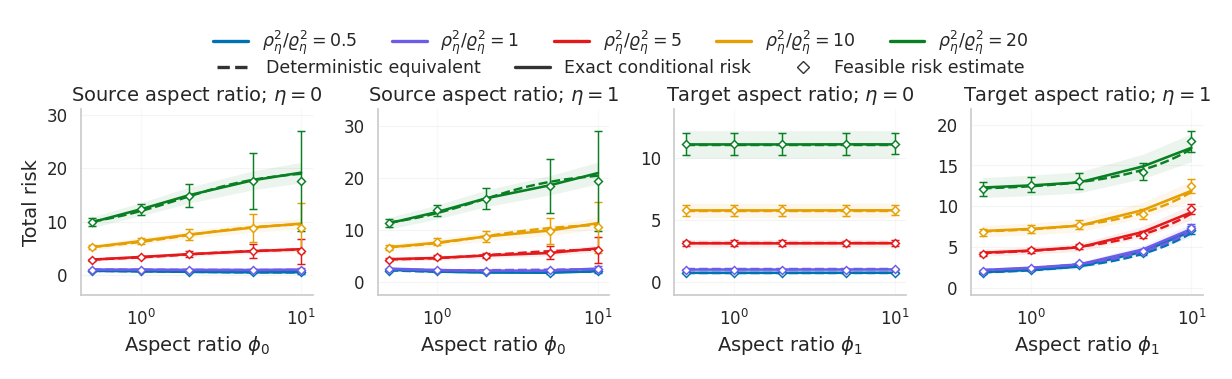

In [3]:
s = pd.read_csv(RESULTS / "ar1_aspect_ratio_summary.csv")
theory = pd.read_csv(RESULTS / "ar1_aspect_theoretical_curves.csv")
phi_curve = np.geomspace(.5, 10, 240)
ratios = (.5, 1., 5., 10., 20.)
ratio_colors = {.5: "#0072B2", 1.: "#6C5CE7", 5.: "#E31A1C",
                10.: "#E69F00", 20.: "#087F23"}

fig,axes=plt.subplots(1,4,figsize=(12,3),squeeze=False)
panels=[("Source",0.),("Source",1.),("Target",0.),("Target",1.)]
for c,(varied,eta) in enumerate(panels):
    ax=axes[0,c]
    for ratio in ratios:
        q=s[(s.varied==varied)&(s.eta==eta)&(s.rho2_over_varrho2==ratio)].sort_values("phi")
        t=theory[(theory.varied==varied)&(theory.eta==eta)&(theory.rho2_over_varrho2==ratio)].sort_values("phi")
        color=ratio_colors[ratio]
        ax.plot(phi_curve,t["Total"].to_numpy(),color=color,ls="--",lw=1.75)
        ax.plot(q.phi,q["exact_total"],color=color,lw=1.85)
        empirical_se=q["exact_total_gaussian_se"].to_numpy(); empirical_mean=q["exact_total"].to_numpy()
        ax.fill_between(q.phi.to_numpy(),np.maximum(empirical_mean-empirical_se,0.0),
                        empirical_mean+empirical_se,color=color,alpha=.08,lw=0)
        ax.errorbar(q.phi,q["estimate_total"],yerr=q["estimate_total_conditional_se"],color=color,
                    marker="D",mfc="white",mew=1.05,ls="none",ms=4.3,
                    capsize=2.6,capthick=1.05,elinewidth=1.05,zorder=7)
    ax.set_xscale("log"); ax.margins(x=.055,y=.15)
    ax.grid(axis="x",alpha=.13); ax.grid(axis="y",alpha=.20)
    ax.set_title(("Source" if varied=="Source" else "Target")+fr" aspect ratio; $\eta={eta:g}$")
    ax.set_xlabel(r"Aspect ratio $\phi_0$" if varied=="Source" else r"Aspect ratio $\phi_1$")
    if c==0: ax.set_ylabel("Total risk")
ratio_handles=[Line2D([0],[0],color=ratio_colors[x],lw=2.4,label=fr"$\rho_\eta^2/\varrho_\eta^2={x:g}$") for x in ratios]
type_handles=[Line2D([0],[0],color=".2",ls="--",label="Deterministic equivalent"),
              Line2D([0],[0],color=".2",label="Exact conditional risk"),
              Line2D([0],[0],color=".2",marker="D",mfc="white",ls="none",label="Feasible risk estimate")]
fig.legend(handles=ratio_handles,loc="upper center",bbox_to_anchor=(.5,1.12),ncol=5,frameon=False)
fig.legend(handles=type_handles,loc="upper center",bbox_to_anchor=(.5,1.02),ncol=3,frameon=False)
fig.subplots_adjust(left=.05,right=.985,bottom=.18,top=.80,wspace=.28)
_save(fig, "02_ar1_aspect_ratio_risk")
plt.show()


## 3. Experiment III: predictive calibration (Figure E9)

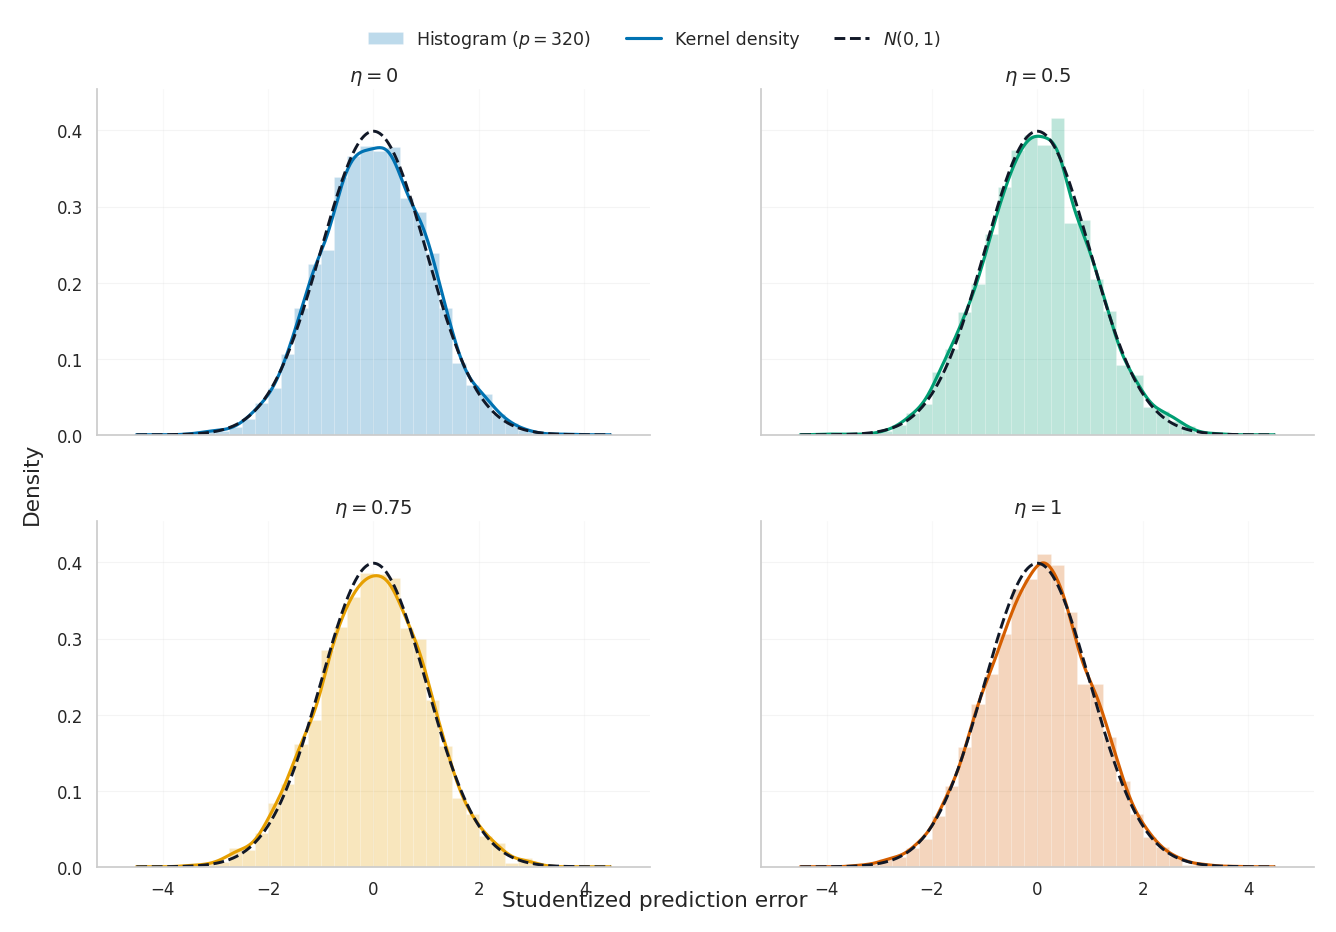

In [4]:
d=pd.read_csv(ARTIFACT_DIR/"risk_tuning_calibration_draws.csv.gz")
fig,axes=plt.subplots(2,2,figsize=(13.6,9.6),sharex=True,sharey=True)
p_display=320
if p_display not in set(d["p"].unique()):
    raise ValueError(f"Requested p={p_display} is absent from the calibration draws.")
xs=np.linspace(-4.5,4.5,451)
bins=np.linspace(-5.0,5.0,41)
bin_width=float(bins[1]-bins[0])
colors=(COLORS["blue"],COLORS["green"],COLORS["gold"],COLORS["vermillion"])
for ax,eta,color in zip(axes.ravel(),CFG.calibration_etas,colors):
    values=d[(d.eta==eta)&(d.p==p_display)].studentized_error.to_numpy()
    # Divide by the full draw count and bin width, so the bars are on a
    # density scale without renormalizing after the finite plotting range.
    weights=np.full(values.shape,1.0/(len(values)*bin_width),dtype=float)
    ax.hist(values,bins=bins,weights=weights,color=color,alpha=.26,
            edgecolor="white",linewidth=.55,label=fr"Histogram ($p={p_display}$)")
    kde=stats.gaussian_kde(values,bw_method="scott")
    ax.plot(xs,kde(xs),color=color,lw=2.25,label="Kernel density")
    ax.plot(xs,stats.norm.pdf(xs),color=COLORS["black"],ls="--",lw=2.1,
            label=r"$N(0,1)$")
    ax.set_title(fr"$\eta={eta:g}$"); ax.margins(x=.025,y=.09)
    ax.grid(axis="x",alpha=.12); ax.grid(axis="y",alpha=.20)
fig.supxlabel("Studentized prediction error",y=.055); fig.supylabel("Density",x=.035)
handles,labels=axes[0,0].get_legend_handles_labels(); fig.legend(handles,labels,loc="upper center",bbox_to_anchor=(.5,.99),ncol=3,frameon=False)
fig.subplots_adjust(left=.09,right=.985,bottom=.1,top=.91,hspace=.25,wspace=.20)
_save(fig, "07_studentized_error_density")
plt.show()


## Appendix E.1: Isotropic risk-path and aspect-ratio controls

The two main-text figures above use the AR(1) covariance `Sigma0 = Sigma1`.
As a control, this subsection repeats the risk-path and aspect-ratio
experiments under the isotropic design `Sigma0 = Sigma1 = I_p` used before
this revision, showing that the anisotropic figures' conclusions are not
artifacts of the AR(1) specification.

*Deterministic equivalent* is the finite-dimensional theory, *exact
conditional risk* the exact risk for the fixed design, and *feasible risk
estimate* the feasible plug-in risk under repeated outcomes.


### Isotropic risk-path grid (Figure 1 control)


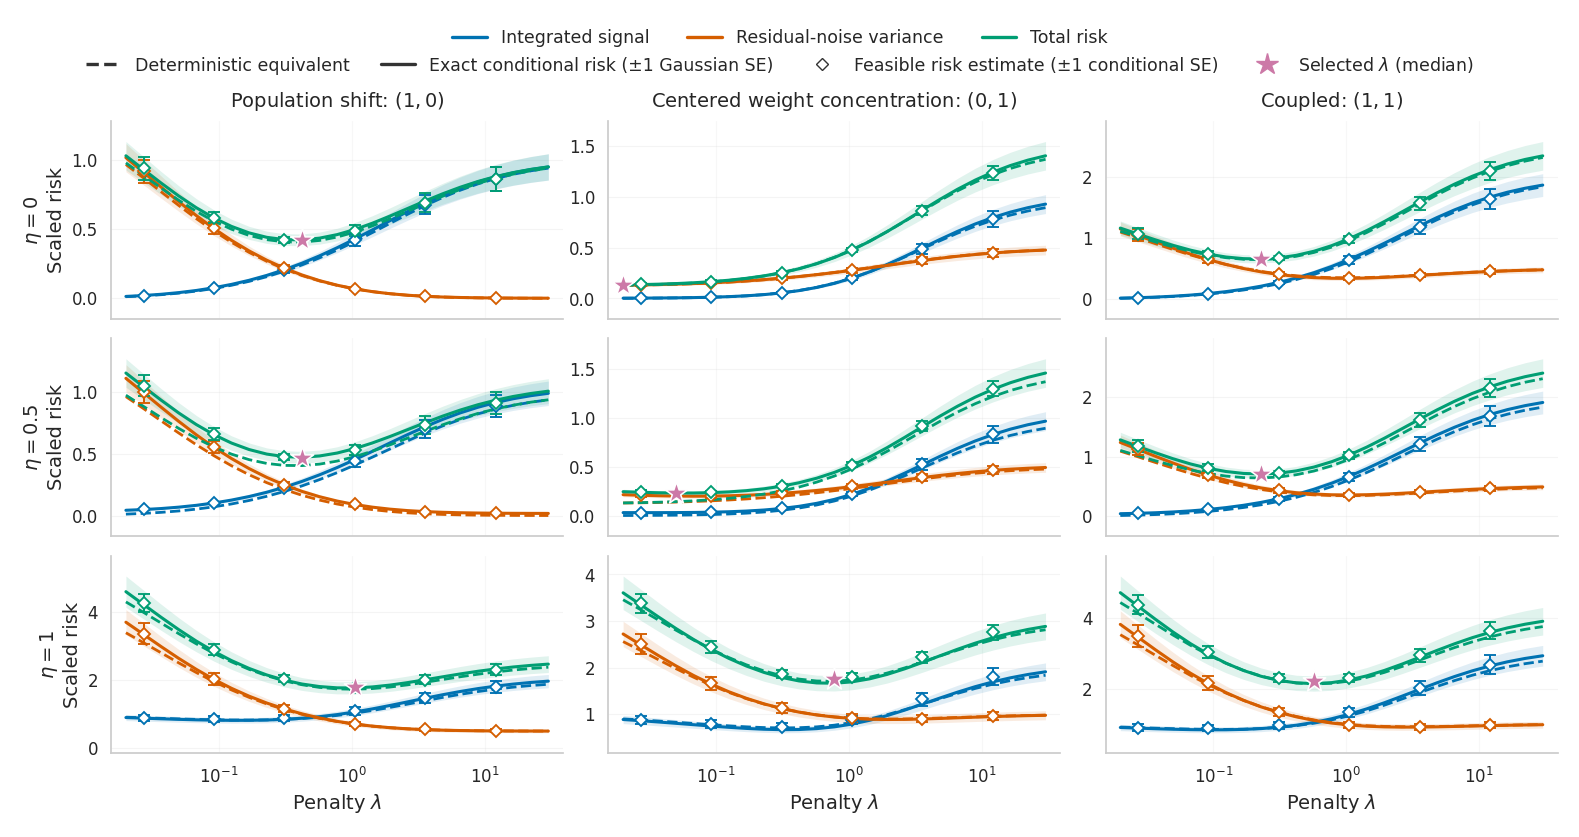

**Isotropic-control uncertainty audit.** The exact-risk envelope is analytic; the risk-estimate bars are sampling SEs of one estimator, not MCSEs of the plotted mean.
                 quantity  fixed covariate designs  outcome repetitions       displayed uncertainty
0  Exact conditional risk                        1                  200     ±1 analytic Gaussian SE
1  Feasible risk estimate                        1                  200  ±1 conditional sampling SE


In [5]:
s = pd.read_csv(RESULTS / "revised_main_risk_summary.csv")
tune = pd.read_csv(RESULTS / "revised_main_selected_lambda.csv")

SCENARIO_TITLES = {
    "Population shift only": r"Population shift: $(1,0)$",
    "Weight concentration only": r"Centered weight concentration: $(0,1)$",
    "Coupled": r"Coupled: $(1,1)$",
}

fig,axes=plt.subplots(3,3,figsize=(16,8),sharex=True,squeeze=False)
point_idx=np.arange(1,len(CFG.lambdas),4)
for r,eta in enumerate(CFG.etas):
    for c,scenario in enumerate(SCENARIOS):
        ax=axes[r,c]; q=s[(s.eta==eta)&(s.scenario==scenario)].sort_values("lambda")
        for comp in COMPONENTS:
            exact,estimate,theory=COMPONENT_COLUMNS[comp]; color=COMPONENT_COLORS[comp]
            ax.plot(q["lambda"],q[theory],color=color,ls="--",lw=2.0)
            ax.plot(q["lambda"],q[exact],color=color,lw=2.2)
            empirical_se=q[f"{exact}_gaussian_se"].to_numpy()
            empirical_mean=q[exact].to_numpy()
            ax.fill_between(q["lambda"].to_numpy(),np.maximum(empirical_mean-empirical_se,0.0),
                            empirical_mean+empirical_se,color=color,alpha=.12,lw=0)
            z=q.iloc[point_idx]
            ax.errorbar(z["lambda"],z[estimate],yerr=z[f"{estimate}_conditional_se"],color=color,
                        marker="D",mfc="white",mew=1.35,ls="none",ms=5.7,
                        capsize=4.0,capthick=1.45,elinewidth=1.45,zorder=7)
        selected=float(tune[(tune.eta==eta)&(tune.scenario==scenario)].selected_lambda.iloc[0])
        j=int(np.argmin(abs(q["lambda"].to_numpy()-selected)))
        ax.scatter(q.iloc[j]["lambda"],q.iloc[j].estimate_total,marker="*",s=285,color=COLORS["purple"],
                   edgecolor="white",linewidth=1.15,zorder=9)
        ax.set_xscale("log"); ax.margins(x=.035,y=.13)
        ax.grid(axis="x",alpha=.14); ax.grid(axis="y",alpha=.20)
        if r==0: ax.set_title(SCENARIO_TITLES[scenario],pad=10)
        if c==0: ax.set_ylabel(fr"$\eta={eta:g}$"+"\nScaled risk")
        if r==2: ax.set_xlabel(r"Penalty $\lambda$")
component=[Line2D([0],[0],color=COMPONENT_COLORS[x],label=COMPONENT_DISPLAY_LABELS[x]) for x in COMPONENTS]
types=[Line2D([0],[0],color=".2",ls="--",label="Deterministic equivalent"),
       Line2D([0],[0],color=".2",label="Exact conditional risk (±1 Gaussian SE)"),
       Line2D([0],[0],color=".2",marker="D",mfc="white",ls="none",label="Feasible risk estimate (±1 conditional SE)"),
       Line2D([0],[0],color=COLORS["purple"],marker="*",ls="none",ms=16,label=r"Selected $\lambda$ (median)")]
fig.legend(handles=component,loc="upper center",bbox_to_anchor=(.5,.995),ncol=3,
           frameon=False,handlelength=2.0,columnspacing=2.2)
fig.legend(handles=types,loc="upper center",bbox_to_anchor=(.5,.963),ncol=4,
           frameon=False,handlelength=2.0,columnspacing=1.8)
fig.subplots_adjust(left=.082,right=.986,bottom=.07,top=.86,hspace=.1,wspace=.1)
_save(fig, "03_isotropic_risk_paths")

uncertainty_audit = pd.DataFrame({
    "quantity": ["Exact conditional risk", "Feasible risk estimate"],
    "fixed covariate designs": [1, 1],
    "outcome repetitions": [int(s["outcome_repetitions"].iloc[0])] * 2,
    "displayed uncertainty": ["\u00b11 analytic Gaussian SE",
                              "\u00b11 conditional sampling SE"],
})
print("**Isotropic-control uncertainty audit.** The exact-risk envelope is analytic; "
    "the risk-estimate bars are sampling SEs of one estimator, not MCSEs of "
    "the plotted mean.")
print(uncertainty_audit.to_string())
plt.show()


### Isotropic aspect-ratio risk paths (Figure 2 control)


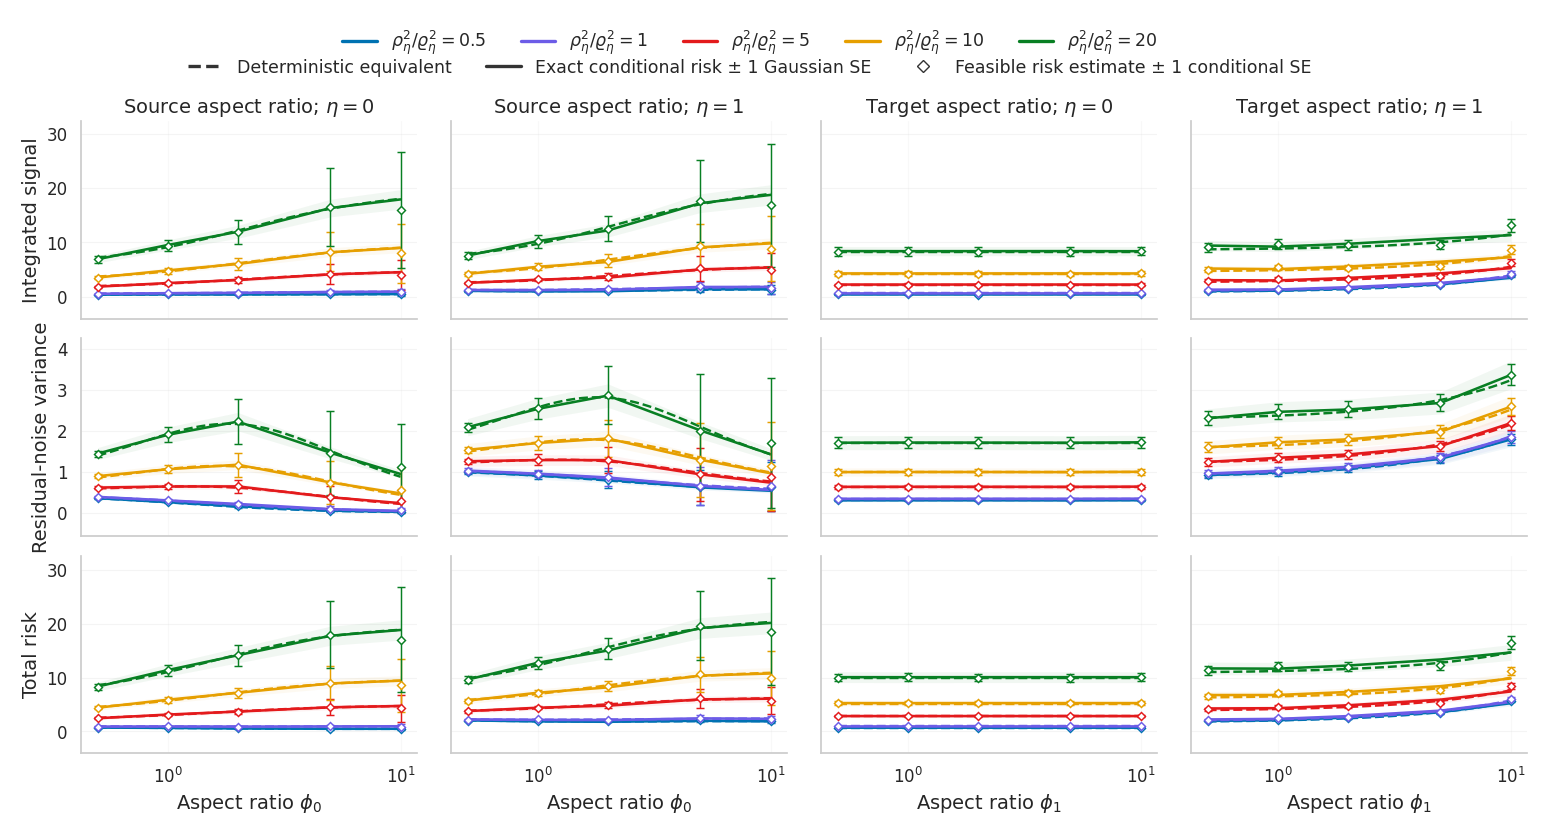

In [6]:
s = pd.read_csv(RESULTS / "revised_aspect_ratio_summary.csv")
theory = pd.read_csv(RESULTS / "revised_aspect_theoretical_curves.csv")
phi_curve = np.geomspace(.5, 10, 240)
ratios = (.5, 1., 5., 10., 20.)
ratio_colors = {.5: "#0072B2", 1.: "#6C5CE7", 5.: "#E31A1C",
                10.: "#E69F00", 20.: "#087F23"}

fig,axes=plt.subplots(3,4,figsize=(16,8),sharex="col",sharey="row",squeeze=False)
panels=[("Source",0.),("Source",1.),("Target",0.),("Target",1.)]
for c,(varied,eta) in enumerate(panels):
    phi0=phi_curve if varied=="Source" else np.full_like(phi_curve,CFG.phi0)
    phi1=phi_curve if varied=="Target" else np.full_like(phi_curve,CFG.phi1)
    for ratio in ratios:
        q=s[(s.varied==varied)&(s.eta==eta)&(s.rho2_over_varrho2==ratio)].sort_values("phi")
        t=theory[(theory.varied==varied)&(theory.eta==eta)
                 &(theory.rho2_over_varrho2==ratio)].sort_values("phi")
        curves={comp:t[comp].to_numpy() for comp in COMPONENTS}
        color=ratio_colors[ratio]
        for r,comp in enumerate(COMPONENTS):
            ax=axes[r,c]; exact,estimate,_=COMPONENT_COLUMNS[comp]
            ax.plot(phi_curve,curves[comp],color=color,ls="--",lw=1.75)
            ax.plot(q.phi,q[exact],color=color,lw=1.85)
            empirical_se=q[f"{exact}_gaussian_se"].to_numpy(); empirical_mean=q[exact].to_numpy()
            ax.fill_between(q.phi.to_numpy(),np.maximum(empirical_mean-empirical_se,0.0),
                            empirical_mean+empirical_se,color=color,alpha=.055,lw=0)
            ax.errorbar(q.phi,q[estimate],yerr=q[f"{estimate}_conditional_se"],color=color,
                        marker="D",mfc="white",mew=1.05,ls="none",ms=4.3,
                        capsize=2.6,capthick=1.05,elinewidth=1.05,zorder=7)
            ax.set_xscale("log"); ax.margins(x=.055,y=.15)
            ax.grid(axis="x",alpha=.13); ax.grid(axis="y",alpha=.20)
            if r==0: ax.set_title(("Source" if varied=="Source" else "Target")+fr" aspect ratio; $\eta={eta:g}$")
            if c==0: ax.set_ylabel(COMPONENT_DISPLAY_LABELS[comp])
            if r==2: ax.set_xlabel(r"Aspect ratio $\phi_0$" if varied=="Source" else r"Aspect ratio $\phi_1$")
ratio_handles=[Line2D([0],[0],color=ratio_colors[x],lw=2.4,label=fr"$\rho_\eta^2/\varrho_\eta^2={x:g}$") for x in ratios]
type_handles=[Line2D([0],[0],color=".2",ls="--",label="Deterministic equivalent"),
              Line2D([0],[0],color=".2",label="Exact conditional risk ± 1 Gaussian SE"),
              Line2D([0],[0],color=".2",marker="D",mfc="white",ls="none",label="Feasible risk estimate ± 1 conditional SE")]
fig.legend(handles=ratio_handles,loc="upper center",bbox_to_anchor=(.5,.995),ncol=5,frameon=False)
fig.legend(handles=type_handles,loc="upper center",bbox_to_anchor=(.5,.958),ncol=3,frameon=False)
fig.subplots_adjust(left=.082,right=.986,bottom=.07,top=.86,hspace=.1,wspace=.1)
_save(fig, "05_isotropic_aspect_ratio_risk")
plt.show()
